In [4]:
# Index finger tracing using webcam, OpenCV, and MediaPipe Tasks API.
import os
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt

from mediapipe.tasks.python import vision
from mediapipe.tasks.python.core import base_options
from mediapipe.tasks.python.vision.core import image as mp_image
from mediapipe.tasks.python.vision.core import vision_task_running_mode as vtrm


def trace_index_finger(duration=8, display=True, camera_index=0, model_path="hand_landmarker.task"):
    """Capture webcam input, trace the index finger tip, and return a matplotlib figure."""
    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f"MediaPipe hand_landmarker task model was not found at '{model_path}'. "
            "Download it from the official MediaPipe model zoo and place it in the working directory."
        )

    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open webcam at index {camera_index}")

    points = []
    start_time = time.time()

    options = vision.HandLandmarkerOptions(
        base_options=base_options.BaseOptions(model_asset_path=model_path),
        running_mode=vtrm.VisionTaskRunningMode.VIDEO,
        num_hands=1,
        min_hand_detection_confidence=0.7,
        min_hand_presence_confidence=0.7,
        min_tracking_confidence=0.7,
    )

    with vision.HandLandmarker.create_from_options(options) as landmarker:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            frame = cv2.flip(frame, 1)
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_img = mp_image.Image(image_format=mp_image.ImageFormat.SRGB, data=rgb_frame)
            timestamp_ms = int((time.time() - start_time) * 1000)
            result = landmarker.detect_for_video(mp_img, timestamp_ms)

            if result.hand_landmarks:
                hand_landmarks = result.hand_landmarks[0]
                index_tip = hand_landmarks[8]
                h, w, _ = frame.shape
                x, y = int(index_tip.x * w), int(index_tip.y * h)
                points.append((x, y))

                # Draw landmarks and index finger trace.
                for landmark_point in hand_landmarks:
                    px, py = int(landmark_point.x * w), int(landmark_point.y * h)
                    cv2.circle(frame, (px, py), 4, (0, 255, 0), -1)
                if len(points) > 1:
                    cv2.polylines(frame, [np.array(points, dtype=np.int32)], False, (255, 0, 0), 2)

            if display:
                cv2.imshow("Index Finger Trace", frame)
                if cv2.waitKey(1) & 0xFF == ord('q'):
                    break

            if time.time() - start_time >= duration:
                break

    cap.release()
    cv2.destroyAllWindows()

    if not points:
        raise RuntimeError("No index finger points were detected during capture.")

    # Build a matplotlib figure of the traced index finger path.
    xs, ys = zip(*points)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(xs, ys, marker='o', color='blue', linewidth=2)
    ax.invert_yaxis()
    ax.set_title("Index Finger Trace")
    ax.set_xlabel("X pixel")
    ax.set_ylabel("Y pixel")
    ax.grid(True, linestyle='--', alpha=0.5)

    return fig


# Example usage:
# fig = trace_index_finger(duration=10, display=True, model_path="hand_landmarker.task")
# fig


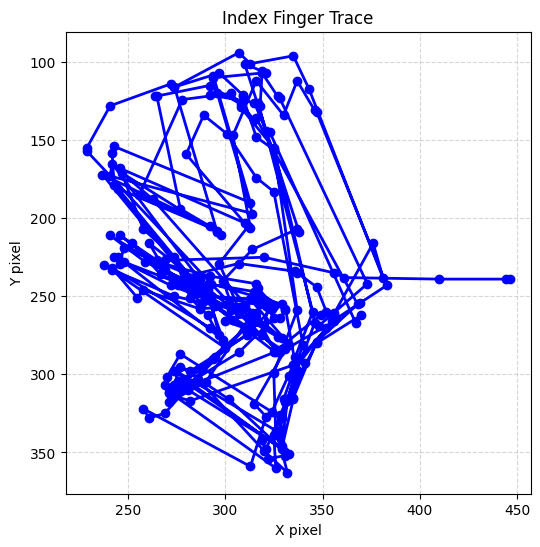

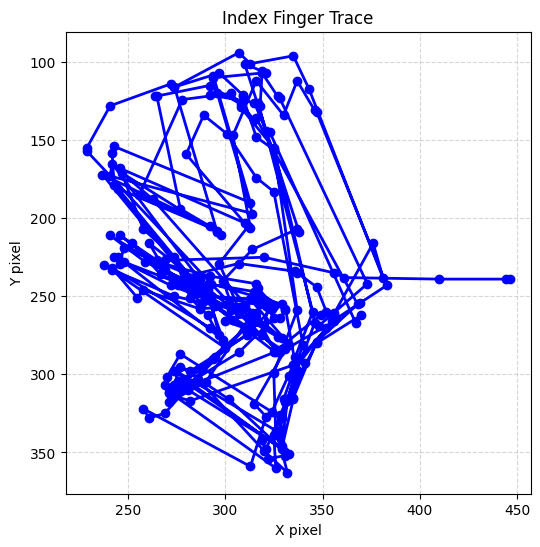

In [ ]:
fig = trace_index_finger(duration=10, display=False, model_path="hand_landmarker.task")
# fig